In [1]:
from data.datasets.synthetic.banana_dataset import BananaDataset
from configs.datasets.synthetic.banana_dataset import BananaDatasetConfig

In [2]:
dataset_config = BananaDatasetConfig()
dataset = BananaDataset(config=dataset_config)
splits = dataset.get_splits()

In [3]:
from data.loaders import make_xy_dataloader

In [4]:
train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=256,
    shuffle=True
)

In [5]:
from predictors.transport.neural_spline_flow import NeuralSplineFlowPredictor
from configs.predictors.transport.neural_spline_flow import NeuralSplineFlowPredictorConfig

In [6]:
predictor_config = NeuralSplineFlowPredictorConfig(x_dim=1, y_dim=2, device='cpu')
predictor = NeuralSplineFlowPredictor(config=predictor_config)

In [7]:
from trainers.transport.neural_spline_flow import NeuralSplineFlowTrainer
from configs.trainers.transport.neural_spline_flow import NeuralSplineFlowTrainerConfig

In [8]:
trainer_config = NeuralSplineFlowTrainerConfig()
trainer = NeuralSplineFlowTrainer(config=trainer_config)

In [9]:
_ = trainer.fit(
    predictor=predictor,
    dataloader=train_dataloader
)

Epoch 100 | NLL 2.8281: 100%|██████████| 100/100 [00:40<00:00,  2.47it/s]


In [10]:
import torch

number_of_eval_samples = 100
condition = torch.ones([number_of_eval_samples, 1]) * 2
ground_truth = dataset.sample_conditional(x=condition, n_samples=1).squeeze()
samples = predictor.sample(condition, n_samples=1).squeeze()

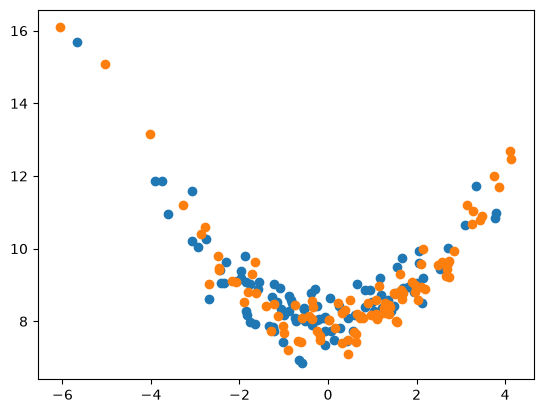

In [13]:
import matplotlib.pyplot as plt

plt.scatter(ground_truth[:, 0], ground_truth[:, 1])
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()